# 04 · Stress tests

A model that scores well once on one test split is not yet trustworthy. These eleven tests probe uncertainty, robustness, fairness and failure modes.

| # | Test | Question |
|---|---|---|
| 1 | Bootstrap CI | How uncertain are the Test metrics? |
| 2 | Missing-data injection | What if more values are missing at inference? |
| 3 | Noise injection | What if measurements are noisier? |
| 4 | Prevalence shift | How do PPV / NPV change in a different population? |
| 5 | Subgroups | Is performance consistent across sex, ethnicity, age and cancer type? |
| 6 | Label noise | What if some training labels are wrong (ClinVar-style misclassification)? |
| 7 | Permutation test | Is the signal real or could it arise by chance? |
| 8 | Learning curve | Would more data help? Is there overfitting? |
| 9 | CV stability | Is performance stable across folds? |
| 10 | Feature knockout | What if the most important features are unavailable? |
| 11 | Edge cases | Does the pipeline survive all-missing rows, extreme values and unseen categories? |

The full suite retrains the models many times (about 4-5 minutes). Set `RUN_FULL = True` to recompute; otherwise the saved results are loaded and re-plotted.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/vus-reclassification


In [2]:
# Make sure the processed splits exist (runs the data stage if needed).
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()

In [3]:
from src.models import stress_test as st
from src.models.train_model import load_models
from src.models.evaluate_model import MODEL_ORDER

needed = ["bootstrap_ci", "missing_injection", "noise_injection", "prevalence_shift", "subgroups",
          "label_noise", "y_scramble", "learning_curve", "cv_stability", "feature_knockout", "edge_cases"]
RUN_FULL = not all((cfg.TABLES_DIR / f"stress_{n}.csv").exists() for n in needed) \
           or not all(p.exists() for p in cfg.MODEL_FILES.values())
if RUN_FULL:
    if not all(p.exists() for p in cfg.MODEL_FILES.values()):
        from src.data import make_dataset; from src.features import build_features as bf
        from src.models import train_model as tm, evaluate_model as em
        make_dataset.main(); bf.run(); tm.run(); em.run(); plt.close("all")
    R = st.run(); plt.close("all")
else:
    R = {n: pd.read_csv(cfg.TABLES_DIR / f"stress_{n}.csv") for n in needed}
    R["summary"] = pd.read_csv(cfg.TABLES_DIR / "stress_test_summary.csv")
print("Loaded" if not RUN_FULL else "Computed", "stress-test results")

Loaded stress-test results


## Scorecard

Model,SVM-RBF,Transformer,XGBoost
Test,,,
1 Bootstrap AUC CI lower bound,PASS,PASS,PASS
11 Input edge cases,PASS,PASS,PASS
2 AUC drop at +30% missing,PASS,PASS,PASS
3 AUC drop at 0.25 SD noise,PASS,PASS,PASS
5 No subgroup significantly below overall AUC,PASS,PASS,PASS
6 AUC drop at 10% label noise,PASS,PASS,PASS
7 Permutation test: real vs null AUC,PASS,PASS,PASS
8 Final Train-Test AUC gap,PASS,PASS,PASS
9 CV fold AUC SD,PASS,PASS,PASS


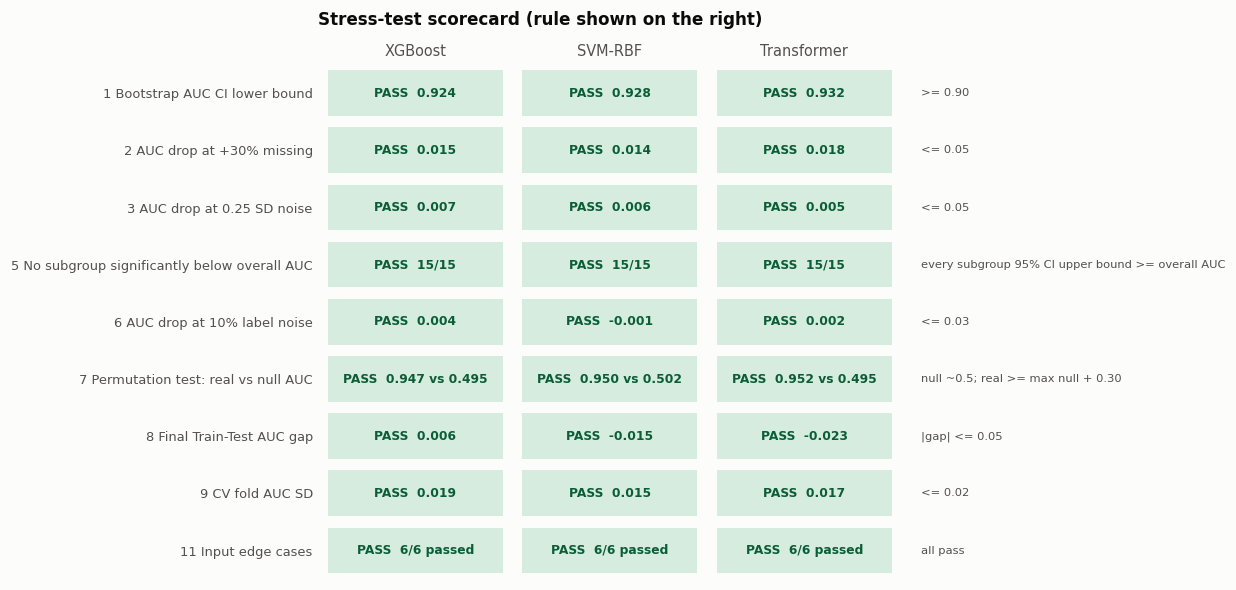

In [4]:
st.plot_summary(R["summary"])
R["summary"].pivot(index="Test", columns="Model", values="Result")

## 1. Bootstrap confidence intervals

Model,SVM-RBF,Transformer,XGBoost
Metric,,,
AUC,0.950,0.952,0.947
Accuracy,0.912,0.896,0.907
F1,0.821,0.799,0.813
NPV,0.973,0.979,0.973
PPV,0.747,0.698,0.734
Sensitivity,0.912,0.934,0.912
Specificity,0.912,0.885,0.906


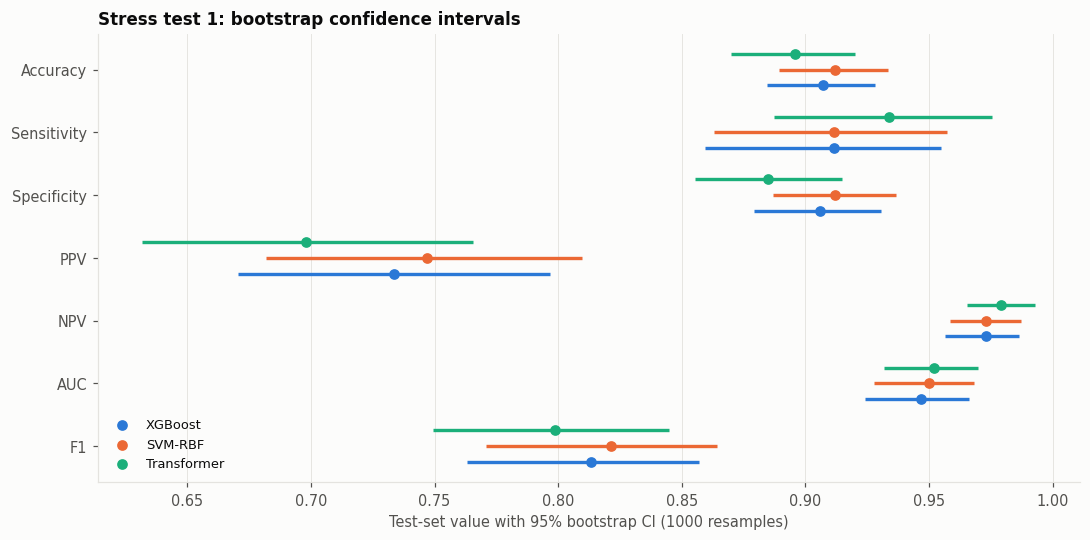

In [5]:
ci = R.get("bootstrap_ci", R.get("bootstrap"))
st.plot_bootstrap(ci)
ci.pivot(index="Metric", columns="Model", values="estimate").round(3)

## 2–3. Missing-data and noise injection
Performance degrades gracefully: +30% missing cells or noise of 0.25 training SDs costs under 0.02 AUC.

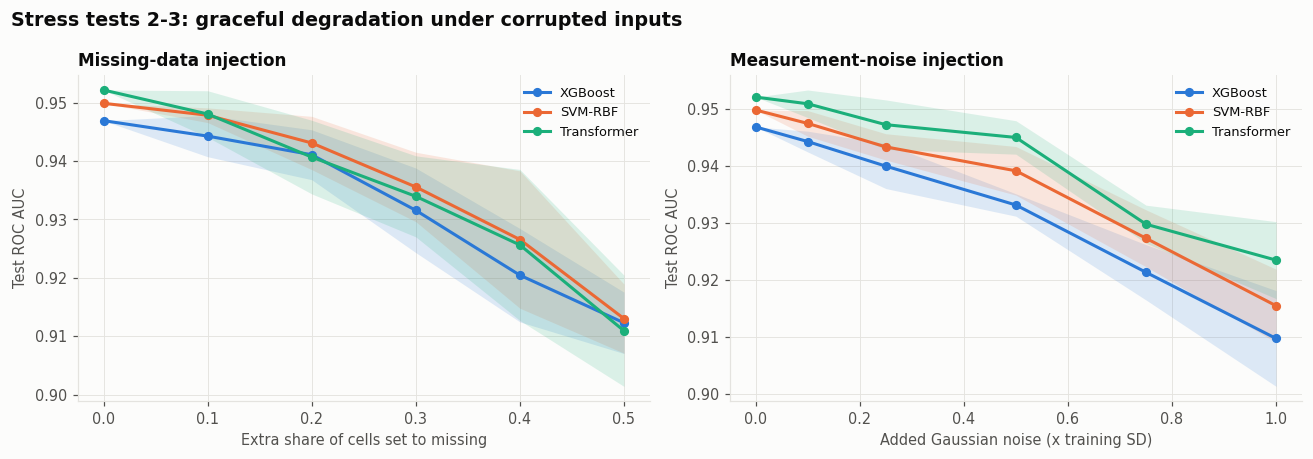

In [6]:
st.plot_degradation(R.get("missing_injection", R.get("missing")), R.get("noise_injection", R.get("noise")));

## 4. Prevalence shift
Sensitivity and specificity are properties of the model; **PPV and NPV depend on prevalence**. In a population where half of the tested variants are pathogenic, PPV rises to about 0.9; at 5% it falls sharply. That is why the lower PPV in the Train/Test table is expected.

Model,SVM-RBF,Transformer,XGBoost
prevalence,,,
0.05,0.356,0.301,0.340
0.10,0.542,0.478,0.522
0.20,0.723,0.673,0.709
0.30,0.817,0.777,0.807
0.40,0.876,0.846,0.867
0.50,0.912,0.890,0.907


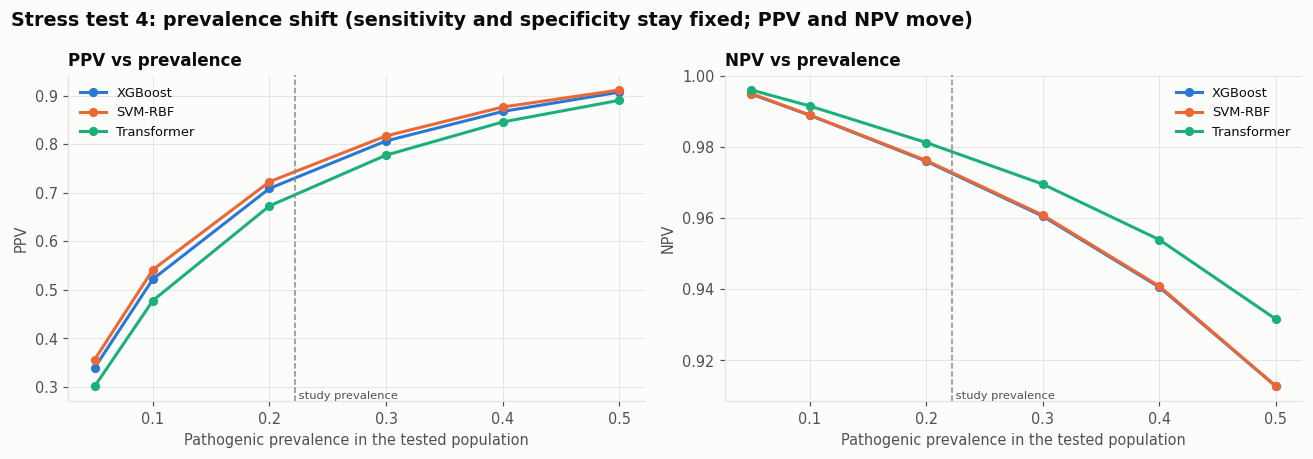

In [7]:
prev = R.get("prevalence_shift", R.get("prevalence"))
st.plot_prevalence(prev)
prev.pivot(index="prevalence", columns="Model", values="PPV").round(3)

## 5. Subgroup (fairness) check
Each subgroup's 95% bootstrap CI is compared with the overall AUC; the concern is any subgroup doing *significantly worse*.

,Model,attribute,group,n,AUC,AUC_ci_low,AUC_ci_high
0,XGBoost,Sex,Female,287,0.962,0.942,0.983
1,XGBoost,Sex,Male,240,0.921,0.874,0.961
2,XGBoost,Ethnicity,Asian,49,0.962,0.876,1.000
3,XGBoost,Ethnicity,Black,85,0.925,0.852,0.976
4,XGBoost,Ethnicity,Hispanic,75,0.931,0.866,0.989
5,XGBoost,Ethnicity,White,292,0.944,0.912,0.972
6,XGBoost,Age_band,45-65,299,0.946,0.917,0.970
7,XGBoost,Age_band,<45,113,0.916,0.849,0.967
8,XGBoost,Age_band,>65,101,0.983,0.955,1.000
9,XGBoost,Cancer_Type,Breast,150,0.951,0.908,0.986


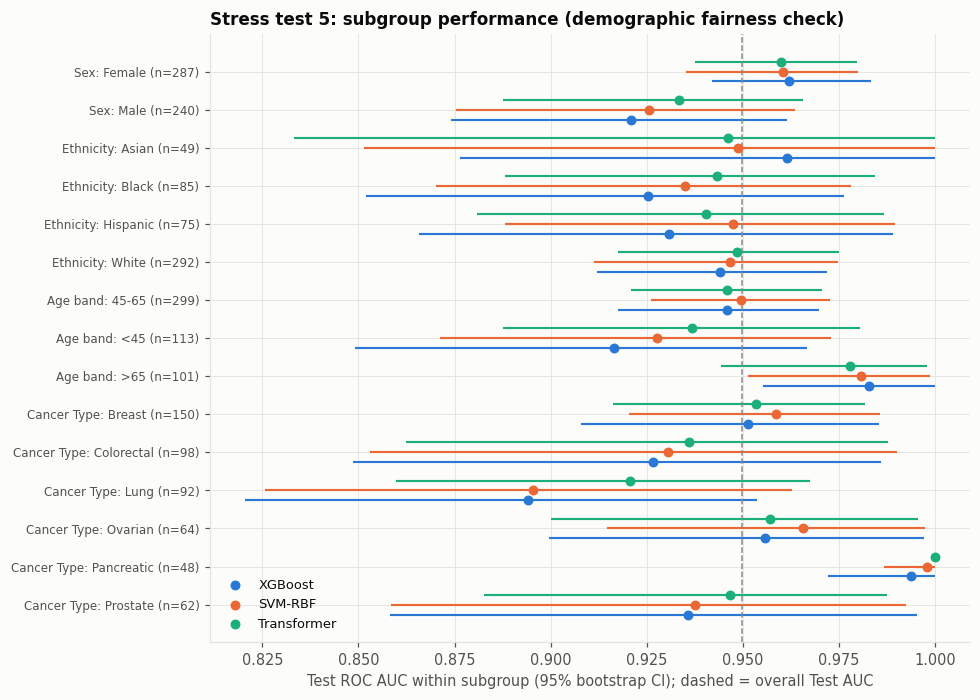

In [8]:
sub = R.get("subgroups")
st.plot_subgroups(sub)
sub[["Model", "attribute", "group", "n", "AUC", "AUC_ci_low", "AUC_ci_high"]].round(3).head(15)

## 6–9. Retraining-based tests
Label noise, the permutation (y-randomisation) test, learning curves and cross-validation stability.

AUC_real        AUC_null       
                mean    max     mean    max
Model                                      
SVM-RBF        0.950  0.950    0.502  0.520
Transformer    0.952  0.952    0.495  0.538
XGBoost        0.947  0.947    0.495  0.524

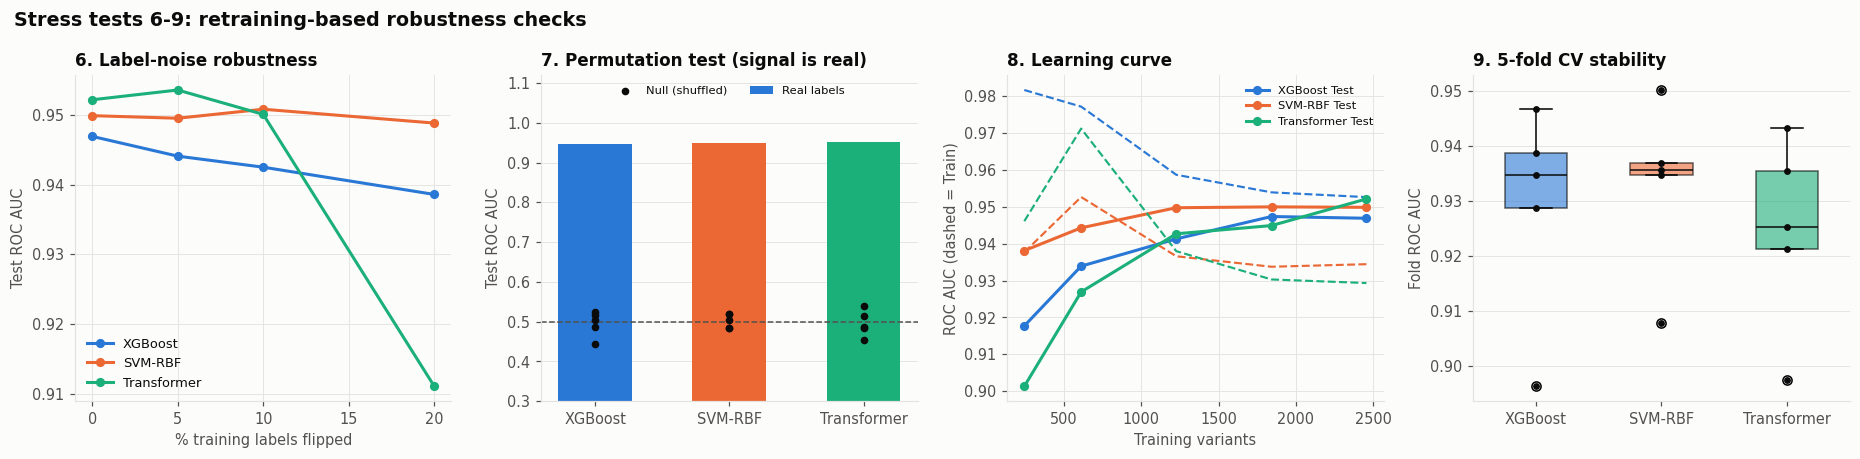

In [9]:
st.plot_retraining(R["label_noise"], R["y_scramble"], R["learning_curve"], R.get("cv_stability", R.get("cv")))
R["y_scramble"].groupby("Model")[["AUC_real", "AUC_null"]].agg(["mean", "max"]).round(3)

## 10. Feature knockout

Model,SVM-RBF,Transformer,XGBoost
features_removed,,,
Variant_Type,0.947,0.946,0.941
"Variant_Type, PolyPhen2_Score",0.943,0.942,0.934
"Variant_Type, PolyPhen2_Score, REVEL_Score",0.938,0.939,0.926
none,0.950,0.952,0.947


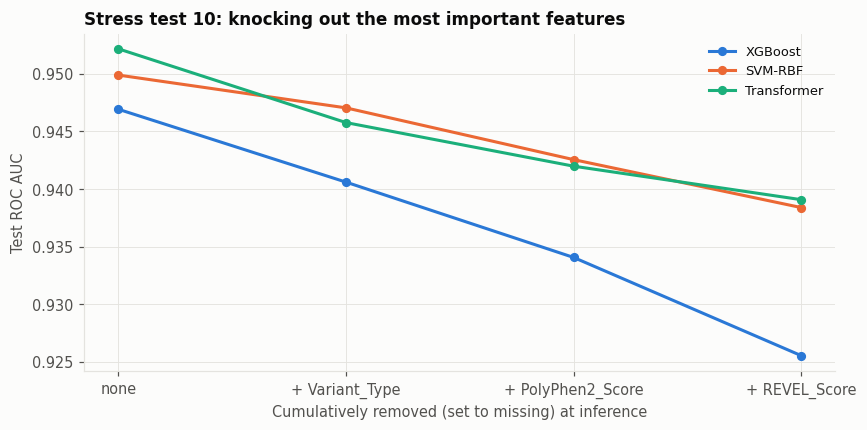

In [10]:
ko = R.get("feature_knockout", R.get("knockout"))
st.plot_knockout(ko)
ko.pivot(index="features_removed", columns="Model", values="AUC").round(3)

## 11. Input edge cases

In [11]:
R.get("edge_cases", R.get("edge"))

,Model,case,passed,detail
0,XGBoost,all_missing_row,True,P range 0.055-0.055
1,XGBoost,extreme_values_x50,True,P range 0.007-0.935
2,XGBoost,extreme_negative_values,True,P range 0.005-0.035
3,XGBoost,unseen_categories,True,P range 0.006-0.847
4,XGBoost,single_row,True,P range 0.018-0.018
5,XGBoost,deterministic_repeat_call,True,max diff 0.00e+00
6,SVM-RBF,all_missing_row,True,P range 0.036-0.036
7,SVM-RBF,extreme_values_x50,True,P range 0.002-1.000
8,SVM-RBF,extreme_negative_values,True,P range 0.000-0.014
9,SVM-RBF,unseen_categories,True,P range 0.005-0.869


**Summary.** All three models pass every rule: tight confidence intervals (AUC lower bound > 0.92), graceful degradation under missing data and noise, no subgroup significantly below the overall AUC, robustness to 10% label noise, a real signal far above the permutation null (≈0.95 vs ≈0.50), small Train-Test gaps, stable folds, and safe behaviour on malformed inputs.